# Logistic Regression Model

In this notebook we train a Logistic Regression model to predict credit default risk. Logistic Regression is our first and simplest model — it serves as the **baseline** that all subsequent models (Random Forest, Gradient Boosting) must outperform to justify their added complexity.

It is a strong starting point for credit risk problems because it is interpretable, fast to train and works well when the relationship between features and the target is approximately linear.

## Importing Libraries

We import the tools needed for model training and evaluation. `LogisticRegression` from scikit-learn is the classifier. The evaluation metrics — accuracy, ROC-AUC, classification report, and confusion matrix (will give us a complete picture of how well the model performs, especially given the class imbalance).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

## Loading the Preprocessed Data

We load the processed arrays saved at the end of the preprocessing notebook. This ensures we use exactly the same train/test split and transformations that were defined there, without repeating any preprocessing steps here.

We also load the feature names so we can inspect which features the model relies on most.

In [2]:
X_train = np.load('../data/X_train_processed.npy')
X_test  = np.load('../data/X_test_processed.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')
feature_names = np.load('../data/feature_names.npy', allow_pickle=True)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape: ', y_test.shape)
print('Number of features:', len(feature_names))

print(f'\nClass distribution in training set:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Good credit' if u == 0 else 'Bad credit'
    print(f'  {label} ({int(u)}): {c} samples ({c/len(y_train)*100:.1f}%)')

X_train shape: (800, 44)
X_test shape:  (200, 44)
y_train shape: (800,)
y_test shape:  (200,)
Number of features: 44

Class distribution in training set:
  Good credit (0): 560 samples (70.0%)
  Bad credit (1): 240 samples (30.0%)


## What is Logistic Regression?

Despite its name, Logistic Regression is a **classification** algorithm, not a regression one. It models the probability that a given applicant belongs to the bad credit class target = 1).

It works by learning a weighted sum of all input features, then passing that sum through the **sigmoid function**, which squashes any value into the range [0, 1]:

$$P(\text{bad credit}) = \frac{1}{1 + e^{-(w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b)}}$$

If the predicted probability is above 0.5, the applicant is classified as bad credit risk.

**Why use it as a baseline for credit risk?**

- It is highly interpretable — each coefficient directly shows the direction and strength
  of a feature's influence on the prediction
- It is fast to train even with many features
- It outputs well-calibrated probabilities, which is important in finance where you often
  need a risk score rather than just a yes/no decision
- Regulators often prefer interpretable models in credit scoring

## Handling Class Imbalance

Our dataset has roughly 70 % good credit applicants and 30 % bad ones. If we train without accounting for this, the model will be biased toward predicting the majority class, it could simply predict 'good credit' for everyone and achieve 70 % accuracy while being completely useless at detecting bad credit.

We use `class_weight='balanced'`, which tells the model to automatically assign higher importance to the minority class (bad credit) during training. Internally, scikit-learn computes weights as:

$$w_i = \frac{\text{total samples}}{\text{number of classes} \times \text{samples in class } i}$$

This means mistakes on the rare class (bad credit) are penalised more heavily,
pushing the model to learn that class better.

## Training the Model

We train Logistic Regression with the following configuration:
- `C=1.0` — the regularisation strength. C is the inverse of regularisation:
  a smaller C means stronger regularisation (simpler model), a larger C means less regularisation. We start with the default value of 1.0 and will tune it if needed.
- `penalty='l2'` — L2 regularisation (Ridge) penalises large coefficients, preventing the model from overfitting to any single feature.
- `solver='lbfgs'` — an efficient optimisation algorithm suitable for our dataset size.
- `max_iter=1000` — we increase the default iterations to ensure the model converges.
- `class_weight='balanced'` — corrects for the 70/30 class imbalance as discussed above.
- `random_state=42` — ensures reproducibility.

In [3]:
lr_model = LogisticRegression(C=1.0,penalty='l2',max_iter=1000,solver='lbfgs',class_weight='balanced',
    random_state=42)

lr_model.fit(X_train, y_train)
print('Model trained successfully.')
print(f'Number of iterations run: {lr_model.n_iter_[0]}')

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Model trained successfully.
Number of iterations run: 39


## Making Predictions

We generate two types of predictions:
- `predict()` returns the hard class label (0 or 1) using a 0.5 probability threshold
- `predict_proba()` returns the probability of each class — we use the probability of the bad credit class (column index 1) to compute the ROC-AUC score, which gives a more nuanced view of model performance than accuracy alone.

In [4]:
y_pred       = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print('Sample predictions (first 10):')
print('Predicted: ', y_pred[:10])
print('Actual:    ', y_test[:10].astype(int))

Sample predictions (first 10):
Predicted:  [0 0 1 1 0 0 0 0 1 0]
Actual:     [0 0 1 0 1 0 0 0 0 0]


## Evaluating the Model

We evaluate using several metrics rather than accuracy alone, because accuracy
is misleading on imbalanced datasets.

- **Accuracy**: percentage of all predictions that are correct. Can be inflated by the majority class.
- **ROC-AUC**: measures the model's ability to distinguish between classes across all possible thresholds. A score of 0.5 means the model is no better than random; a score of 1.0 means perfect separation. This is the most important single metric for imbalanced classification.
- **Precision**: of all applicants predicted as bad credit, how many actually were?
- **Recall**: of all actual bad credit applicants, how many did we catch?
- **F1-score**: the harmonic mean of precision and recall, balancing both.

In credit risk, **recall for the bad credit class is especially important**, missing a bad applicant (false negative) is more costly than wrongly flagging a good one.

In [5]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print('       LOGISTIC REGRESSION RESULTS')
print('=' * 45)
print(f'  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  ROC-AUC  : {roc_auc:.4f}')
print('=' * 45)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Good Credit', 'Bad Credit']))

       LOGISTIC REGRESSION RESULTS
  Accuracy : 0.7250 (72.50%)
  ROC-AUC  : 0.7819

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.88      0.71      0.78       140
  Bad Credit       0.53      0.77      0.63        60

    accuracy                           0.72       200
   macro avg       0.70      0.74      0.70       200
weighted avg       0.77      0.72      0.74       200



The model achieved a ROC-AUC of 0.78, which is a solid baseline for a linear model. For the Bad Credit class, recall is 0.77 — meaning the model correctly caught 77% of actual bad applicants. This is the most important metric in credit risk since missing a bad applicant is more costly than wrongly flagging a good one. However, precision is only 0.53, meaning roughly half of the applicants flagged as bad were actually good — a direct consequence of using class_weight='balanced'.

This tradeoff is intentional and acceptable for a baseline. We expect Random Forest and Gradient Boosting to improve on these numbers.

## Confusion Matrix

The confusion matrix shows the exact breakdown of correct and incorrect predictions:

- **True Negatives (top-left)** — correctly predicted as good credit
- **False Positives (top-right)** — good credit applicants wrongly flagged as bad
- **False Negatives (bottom-left)** — bad credit applicants we missed ← most costly
- **True Positives (bottom-right)** — correctly identified bad credit applicants

In a credit risk context, False Negatives (missed bad applicants) result in approved loans that default, the most expensive type of error for a bank.

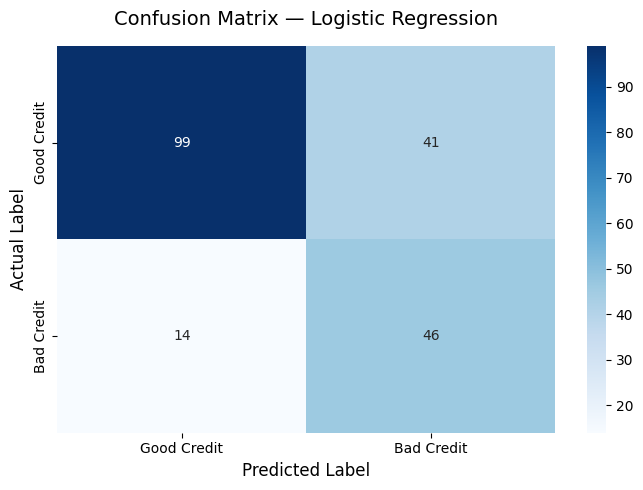

True Negatives  (correctly predicted good): 99
False Positives (good applicants flagged):  41
False Negatives (bad applicants missed):    14  ← most costly
True Positives  (correctly caught bad):     46


In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Good Credit', 'Bad Credit'],
    yticklabels=['Good Credit', 'Bad Credit']
)
plt.title('Confusion Matrix — Logistic Regression', fontsize=14, pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted good): {tn}')
print(f'False Positives (good applicants flagged):  {fp}')
print(f'False Negatives (bad applicants missed):    {fn}  ← most costly')
print(f'True Positives  (correctly caught bad):     {tp}')

Out of 200 test applicants, the model correctly classified 99 good credit and 46 bad credit applicants.

The most important number is the 14 False Negatives — bad applicants the model missed and approved. With only 60 actual bad applicants in the test set, missing 14 means the model let through 23% of all bad applicants, which in a real banking scenario represents 23% of loans that would default.

On the other side, 41 False Positives (good applicants wrongly rejected) is the price we pay for being cautious. This is acceptable since rejecting a good customer is far less damaging than approving a defaulting loan.

## ROC Curve

The ROC (Receiver Operating Characteristic) curve plots the **True Positive Rate** against the **False Positive Rate** at very possible classification threshold.

A model that predicts randomly would follow the diagonal ashed line (AUC = 0.5). The further the curve bends toward the top-left corner, the better the model is at separating good and bad credit applicants.

The **Area Under the Curve (AUC)** summarises this into a single number our target for a good credit risk model is AUC > 0.75.

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


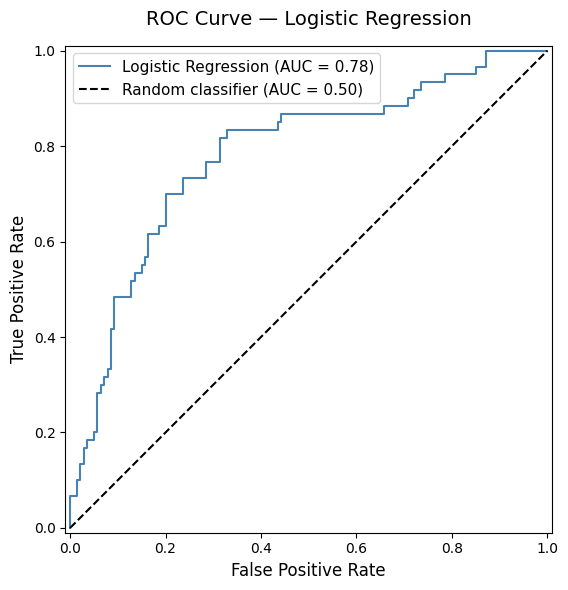

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test,y_pred_proba,name='Logistic Regression', color='steelblue',ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUC = 0.50)')
ax.set_title('ROC Curve — Logistic Regression', fontsize=14, pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The curve sits clearly above the diagonal dashed line, confirming the model performs significantly better than random guessing.

The AUC of 0.78 means the model has a 78% chance of correctly ranking a bad applicant as riskier than a good one. The curve rises steeply in the early left region, which is the ideal behaviour — it means the model catches a large proportion of bad applicants while generating very few false alarms at low thresholds.

This will serve as our baseline to beat in the next two models.

## Feature Importance — Model Coefficients

One of the main advantages of Logistic Regression is interpretability.
Each feature has a learned coefficient that tells us:

- **Positive coefficient** → higher values of that feature increase the probability
  of bad credit
- **Negative coefficient** → higher values decrease the probability of bad credit
- **Larger absolute value** → stronger influence on the prediction

We plot the top 20 most influential features to understand what the model
learned about credit risk in this dataset.

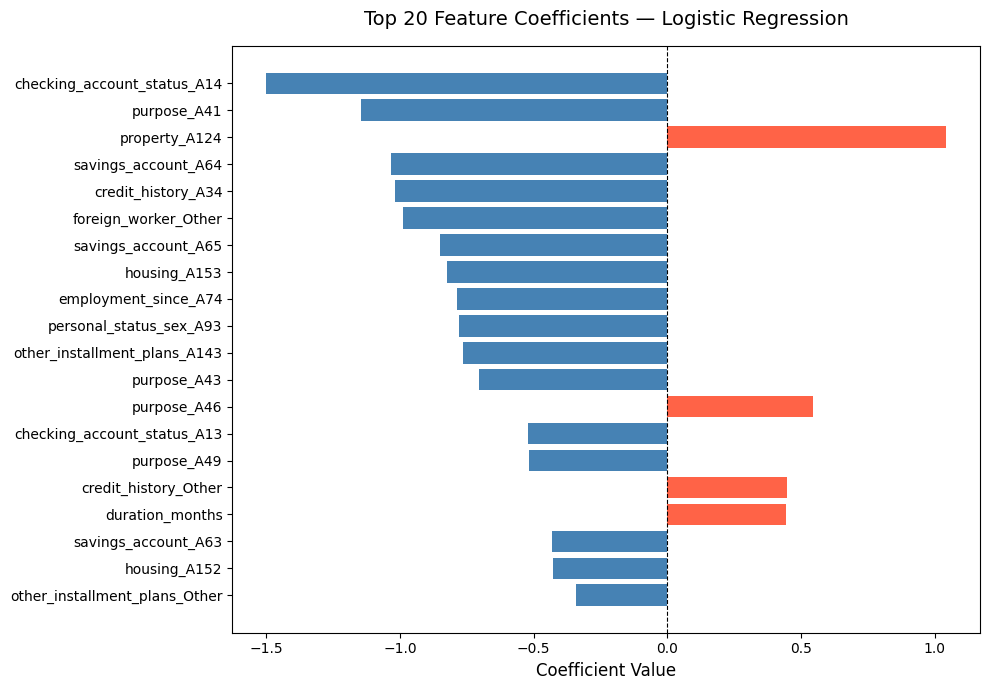

Top 10 features increasing bad credit risk (positive coefficients):
property_A124           1.0423
purpose_A46             0.5459
credit_history_Other    0.4463
duration_months         0.4419
installment_rate        0.3010
property_A123           0.2462
property_A122           0.1630
credit_amount           0.1320
existing_credits        0.1280
employment_since_A72    0.1160
dtype: float64

Top 10 features decreasing bad credit risk (negative coefficients):
checking_account_status_A14    -1.5006
purpose_A41                    -1.1457
savings_account_A64            -1.0323
credit_history_A34             -1.0173
foreign_worker_Other           -0.9885
savings_account_A65            -0.8498
housing_A153                   -0.8238
employment_since_A74           -0.7881
personal_status_sex_A93        -0.7811
other_installment_plans_A143   -0.7637
dtype: float64


In [8]:
coefficients = pd.Series(lr_model.coef_[0], index=feature_names)
top_features = coefficients.abs().sort_values(ascending=False).head(20)
top_coefs    = coefficients[top_features.index]

colors = ['tomato' if c > 0 else 'steelblue' for c in top_coefs.values]

plt.figure(figsize=(10, 7))
bars = plt.barh(range(len(top_coefs)), top_coefs.values[::-1], color=colors[::-1])
plt.yticks(range(len(top_coefs)), top_coefs.index[::-1], fontsize=10)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 20 Feature Coefficients — Logistic Regression', fontsize=14, pad=15)
plt.xlabel('Coefficient Value', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 10 features increasing bad credit risk (positive coefficients):')
print(coefficients.sort_values(ascending=False).head(10).round(4))
print()
print('Top 10 features decreasing bad credit risk (negative coefficients):')
print(coefficients.sort_values(ascending=True).head(10).round(4))

The most influential feature increasing bad credit risk is `property_A124` (no property/unknown) with a coefficient of 1.04 — applicants with no property are significantly more likely to default, which makes intuitive sense as property represents financial stability.
`duration_months` (0.44) and `credit_amount` (0.13) also push toward bad credit — longer and larger loans carry higher default risk.

On the other side, `checking_account_status_A14` is the strongest protective factor (-1.50) — having no checking account at all is associated with good credit, likely because these applicants tend to be financially conservative. `credit_history_A34` (-1.02) being negative confirms that applicants with a critical credit history are already known to the bank and treated cautiously, while `savings_account_A64` (-1.03) shows that having savings above 1000 strongly reduces default risk.

These findings align well with financial intuition and give us confidence that the model learned meaningful patterns rather than noise.

## Saving the Model

We save the trained model so it can be loaded in the model evaluation notebook where all three models (Logistic Regression, Random Forest, Gradient Boosting) will be compared side by side.

We also save the key metrics to a dictionary for easy comparison later.

In [9]:
os.makedirs('../models', exist_ok=True)

joblib.dump(lr_model, '../models/logistic_regression.pkl')
print('Model saved to ../models/logistic_regression.pkl')

lr_metrics = {
    'model': 'Logistic Regression',
    'accuracy': round(accuracy_score(y_test, y_pred), 4),
    'roc_auc':  round(roc_auc_score(y_test, y_pred_proba), 4)
}

print()
print('Metrics summary:')
for k, v in lr_metrics.items():
    print(f'  {k}: {v}')

Model saved to ../models/logistic_regression.pkl

Metrics summary:
  model: Logistic Regression
  accuracy: 0.725
  roc_auc: 0.7819
